# Reconstruyendo "Mapping the Diversity of Galaxy Spectra" con DESOM
# By Gabriel Velazquez
## Objetivo:
Replicar a escala la metodología de aprendizaje no supervisado propuesta por Teimoorinia et al. (2021) para organizar y resumir la diversidad de espectros de galaxias utilizando un Deep Embedded Self-Organizing Map (DESOM).

A diferencia de las redes neuronales tradicionales que requieren etiquetas, aquí utilizaremos el DESOM para que descubra por sí mismo las similitudes físicas en los espectros, creando un mapa 2D donde los espectros similares (por ejemplo, estrellas jóvenes vs. viejas) terminen en vecindarios cercanos. Finalmente, usaremos este mapa para crear la "huella dactilar" (fingerprint) espacial de cada galaxia.

---

### Contexto Astronómico: ¿Qué datos estamos manejando?
En astronomía clásica, se tomaba un solo espectro para toda una galaxia. En este proyecto utilizamos datos de **MaNGA (Mapping Nearby Galaxies at Apache Point Observatory)**. MaNGA utiliza la técnica de **Espectroscopía de Campo Integral (IFU)**.

En lugar de un solo espectro, obtenemos un "cubo de datos" que contiene un espectro individual para cada región espacial de la galaxia (llamados **spaxels** o píxeles espaciales). Cada espectro es una firma de luz que nos dice qué elementos químicos hay, la edad de las estrellas y si hay formación estelar en esa coordenada específica.

In [ ]:
%pip -q install astropy requests torch matplotlib numpy

from pathlib import Path
import random
import numpy as np
import requests
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from astropy.io import fits
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset

# Fijar semillas para reproducibilidad
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Dispositivo utilizado:", device)

DATA = Path("/content/manga_demo")
DATA.mkdir(exist_ok=True)

# Selección de 3 galaxias de prueba del catálogo oficial SDSS DR17.
GALAXIES = ["7443-12703", "8082-12704", "8081-1901"]
BASE = "https://data.sdss.org/sas/dr17/manga/spectro/redux/v3_1_1"

# Estandarización de la rejilla de longitudes de onda en reposo (3650 a 8950 Å) a 4544 puntos.
wave_grid = np.linspace(3650, 8950, 4544)

Dispositivo utilizado: cpu


## Preprocesamiento de Espectros

1. **Corrección del Corrimiento al Rojo (De-redshifting):** El universo se expande, por lo que la luz de las galaxias nos llega desplazada hacia el rojo. Dividimos las longitudes de onda observadas por $(1 + z)$ (donde $z$ es el corrimiento al rojo) para devolver el espectro a su estado de "reposo". Esto nos permite comparar galaxias como si estuvieran a la misma distancia.
2. **Enmascaramiento del Cielo (Sky Masking):** La atmósfera terrestre contamina los datos. Eliminamos las firmas de las líneas de emisión terrestre, como el oxígeno a 5577 Å y 6300 Å, y la emisión de Sodio (NaD) a 5895 Å.
3. **Normalización del Continuo:** El brillo total varía mucho dependiendo del tamaño de la galaxia. Dividimos cada espectro por su flujo medio en el rango de 4050 a 4150 Å. Así, la red neuronal se enfocará en la *forma* del espectro y en las líneas de absorción/emisión, no en su brillo absoluto.

In [ ]:
import pandas as pd

def download(url, destination):
    if destination.exists():
        return destination
    temporary = destination.with_suffix(destination.suffix + "..part")
    with requests.get(url, stream=True, timeout=(30, 180)) as response:
        response.raise_for_status()
        with open(temporary, "wb") as output:
            for chunk in response.iter_content(1024 * 1024):
                if chunk:
                    output.write(chunk)
    temporary.replace(destination)
    return destination

print("Descargando catálogo drpall...")
catalog_path = download(f"{BASE}/drpall-v3_1_1.fits", DATA / "drpall.fits")
with fits.open(catalog_path, memmap=False) as hdul:
    catalog = hdul[1].data.copy()

def as_text(value):
    return value.decode().strip() if isinstance(value, bytes) else str(value).strip()

catalog_ids = np.array([as_text(v) for v in catalog["plateifu"]])

# Crear y visualizar un DataFrame de Pandas con las galaxias elegidas de drpall
selected_rows = [np.flatnonzero(catalog_ids == gal)[0] for gal in GALAXIES if len(np.flatnonzero(catalog_ids == gal)) == 1]
columns_to_show = ["plateifu", "nsa_z", "objra", "objdec", "mangaid", "ifudesignsize"]
df_catalog = pd.DataFrame({col: [catalog[col][r] if col != "plateifu" else as_text(catalog[col][r]) for r in selected_rows] for col in columns_to_show})
display(df_catalog)

spectra, owners, positions = [], [], []
rng = np.random.default_rng(SEED)

print("\nProcesando cubos IFU de las galaxias seleccionadas...")
for galaxy in GALAXIES:
    rows = np.flatnonzero(catalog_ids == galaxy)
    if len(rows) != 1:
        raise ValueError(f"Entrada de catálogo no única para {galaxy}")

    # Obtener el corrimiento al rojo (z) del catálogo
    z = float(catalog["nsa_z"][rows[0]])
    if not np.isfinite(z) or not 0 < z < 0.15:
        continue

    plate, ifu = galaxy.split("-")
    filename = f"manga-{galaxy}-LOGCUBE.fits.gz"
    path = download(f"{BASE}/{plate}/stack/{filename}", DATA / filename)

    selected, coordinates = [], []
    with fits.open(path, memmap=False) as hdul:
        observed = np.asarray(hdul["WAVE"].data, dtype=float)
        # 1. De-redshifting (llevar al reposo)
        rest = observed / (1 + z)
        flux = hdul["FLUX"].data
        ivar = hdul["IVAR"].data
        mask = hdul["MASK"].data

        # Rango de interés dictado por el paper (3650 a 8950 Å)
        region = (rest >= 3650) & (rest <= 8950)
        continuum = (rest >= 4050) & (rest <= 4150)

        # 2. Enmascaramiento de líneas terrestres
        sky_ok = np.ones(len(rest), dtype=bool)
        for sky_line in [5577, 5895, 6300]:
            sky_ok &= np.abs(observed - sky_line) > 8

        # Iterar sobre las dimensiones espaciales (y, x) del IFU para extraer spaxels
        for y, x in np.ndindex(flux.shape[1:]):
            f = np.asarray(flux[:, y, x], dtype=float)
            v = np.asarray(ivar[:, y, x], dtype=float)

            # Filtro de calidad y Relación Señal/Ruido (S/N)
            good = (np.isfinite(f) & np.isfinite(v) & (v > 0) & (mask[:, y, x] == 0) & sky_ok)
            c = good & continuum
            if c.sum() < 20 or np.median(f[c] * np.sqrt(v[c])) < 10:
                continue
            if (good & region).sum() / region.sum() < 0.95:
                continue

            # 3. Normalización
            norm = f[c].mean()
            if not np.isfinite(norm) or norm <= 0:
                continue

            w = rest[good]
            if w[0] > wave_grid[0] or w[-1] < wave_grid[-1]:
                continue

            # Interpolación a la rejilla estándar de 4544 puntos
            spectrum = np.interp(wave_grid, w, f[good]) / norm
            if np.isfinite(spectrum).all():
                selected.append(spectrum.astype("float32"))
                coordinates.append((y, x))

    if len(selected) < 50:
        print(f"  -> {galaxy} omitida (espectros insuficientes)")
        continue

    # Limitar para experimentación rápida
    take = rng.choice(len(selected), min(600, len(selected)), replace=False)
    spectra.extend([selected[i] for i in take])
    positions.extend([coordinates[i] for i in take])
    owners.extend([galaxy] * len(take))
    print(f"  -> {galaxy} procesada. z={z:.4f} | Espectros extraídos={len(take)}")

X = np.stack(spectra)
owners = np.asarray(owners)
positions = np.asarray(positions)

# Separar la última galaxia como conjunto de prueba (out-of-sample)
train_mask = owners != GALAXIES[-1]
test_mask = ~train_mask
X_train = torch.from_numpy(X[train_mask])
X_test = torch.from_numpy(X[test_mask])

print(f"\nDatos Listos. Entrenamiento: {X_train.shape} | Prueba: {X_test.shape}")

Descargando catálogo drpall...


,plateifu,nsa_z,objra,objdec,mangaid,ifudesignsize
0,7443-12703,0.040272,229.525576,42.745842,12-193481,127
1,8082-12704,0.131681,49.949562,-0.221145,1-109308,127
2,8081-1901,0.027045,47.914895,0.781729,1-37931,19



Procesando cubos IFU de las galaxias seleccionadas...
  -> 7443-12703 procesada. z=0.0403 | Espectros extraídos=600
  -> 8082-12704 procesada. z=0.1317 | Espectros extraídos=79
  -> 8081-1901 procesada. z=0.0270 | Espectros extraídos=148

Datos Listos. Entrenamiento: torch.Size([679, 4544]) | Prueba: torch.Size([148, 4544])


El Algoritmo: DESOM (Deep Embedded Self-Organizing Map)

Manejar espectros con 4544 puntos (dimensiones) es muy costoso para un SOM clásico. La arquitectura **DESOM** resuelve esto usando un **Autoencoder**.
1. **Encoder:** Comprime los 4544 puntos de flujo en un "espacio latente" denso (para esta demo, 32 dimensiones. *El artículo original usa 256 dimensiones y capas convolucionales*).
2. **Capa SOM:** Organiza estos vectores latentes en una cuadrícula topológica (5x5 para esta demo, 15x15 en el paper) donde los nodos compiten por representar la entrada.
3. **Decoder:** Reconstruye el espectro original a partir de la representación comprimida, lo que obliga al modelo a no perder información física importante durante la compresión.

*La función de pérdida* optimiza simultáneamente la fidelidad del espectro (Mean Squared Error) y la coherencia topológica del mapa SOM.



---


### Formulación Matemática de DESOM y sus Pérdidas

El entrenamiento conjunto de DESOM optimiza simultáneamente la reconstrucción del Autoencoder y la autoorganización del mapa (SOM). La función de pérdida total se define como:

$$L_{\text{total}} = L_{\text{rec}} + \gamma \cdot L_{\text{som}}$$

Donde:
*   $\gamma$ (`GAMMA`): Es una constante (hiperparámetro) de peso que controla el balance entre la fidelidad de la reconstrucción física y el ordenamiento topológico del mapa. En nuestra demo, $\gamma = 0.05$.

#### 1. Pérdida de Reconstrucción ($L_{\text{rec}}$)
Mide la capacidad del Autoencoder para comprimir y reconstruir el espectro sin perder sus características esenciales (como líneas de absorción y emisión):

$$L_{\text{rec}} = \frac{1}{N} \sum_{i=1}^{N} \|x_i - \hat{x}_i\|^2$$

*   $x_i$: Es el espectro de galaxia original de entrada (un vector de dimensión $d = 4544$).
*   $\hat{x}_i$: Es el espectro reconstruido por el Decoder a partir de su representación latente ($g(f(x_i))$).
*   $N$: Tamaño del lote (batch size).

#### 2. Pérdida del SOM ($L_{\text{som}}$)
Fuerza a que las representaciones latentes $z_i = f(x_i)$ se agrupen de manera topológica en el mapa:

$$L_{\text{som}} = \frac{1}{N} \sum_{i=1}^{N} \frac{\sum_{j=1}^{M} K_{\sigma}(w_i, j) \|z_i - m_j\|^2}{\sum_{j=1}^{M} K_{\sigma}(w_i, j)}$$

*   $z_i$: Representación latente del espectro $i$ en el espacio de dimensión baja ($d_{\text{latent}} = 32$).
*   $m_j$: Vector prototipo (pesos) del nodo $j$ en el mapa latente ($M = 25$ nodos para una cuadrícula de $5 \times 5$).
*   $w_i$: El nodo ganador (*Best Matching Unit* o BMU) para el dato $i$, definido matemáticamente como el prototipo más cercano:

    $$w_i = \arg\min_{j} \|z_i - m_j\|^2$$

*   $K_{\sigma}(w_i, j)$: Función de vecindad kernel de Gauss que distribuye la actualización a los nodos vecinos en la cuadrícula 2D:

    $$K_{\sigma}(w_i, j) = \exp\left(-\frac{\delta(w_i, j)^2}{2\sigma^2}\right)$$

    *   $\delta(w_i, j)$: Distancia euclidiana en el espacio bidimensional de la cuadrícula (coordenadas discretas $x, y$) entre el nodo ganador $w_i$ y el nodo $j$.
    *   $\sigma$ (`temperature`): Temperatura o radio de vecindad que decrece exponencialmente con las épocas para permitir una transición de un aprendizaje global a uno local fino.

In [ ]:
SIDE, LATENT = 5, 32
PRETRAIN_EPOCHS, JOINT_EPOCHS = 20, 40
GAMMA = 0.05 # Peso de la pérdida del SOM frente al error de reconstrucción

class DESOM(nn.Module):
    def __init__(self, n_features):
        super().__init__()
        # Para acelerar la demo usamos capas Densas.
        self.encoder = nn.Sequential(
            nn.Linear(n_features, 256), nn.ReLU(),
            nn.Linear(256, LATENT)
        )
        self.decoder = nn.Sequential(
            nn.Linear(LATENT, 256), nn.ReLU(),
            nn.Linear(256, n_features)
        )
        # Los "prototipos" son los nodos del SOM en el espacio latente
        self.prototypes = nn.Parameter(torch.randn(SIDE * SIDE, LATENT))

model = DESOM(X.shape[1]).to(device)
loader = DataLoader(
    TensorDataset(X_train), batch_size=64, shuffle=True,
    generator=torch.Generator().manual_seed(SEED)
)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# Distancias en la cuadrícula topológica del SOM (cooperación espacial)
grid = torch.cartesian_prod(torch.arange(SIDE), torch.arange(SIDE)).float().to(device)
grid_d2 = torch.cdist(grid, grid).square()

history = []

print("Entrenando Modelo DESOM...")
for epoch in range(PRETRAIN_EPOCHS + JOINT_EPOCHS):
    joint = epoch >= PRETRAIN_EPOCHS

    # Pre-entrenamiento: Inicializar prototipos del SOM usando datos codificados
    if epoch == PRETRAIN_EPOCHS:
        model.eval()
        with torch.no_grad():
            indices = torch.randperm(len(X_train))[:SIDE * SIDE]
            model.prototypes.copy_(model.encoder(X_train[indices].to(device)))

    model.train()
    total_rec, total_som, count = 0., 0., 0

    if joint:
        progress = (epoch - PRETRAIN_EPOCHS) / max(JOINT_EPOCHS - 1, 1)
        temperature = 3.0 * (0.5 / 3.0) ** progress

    for (batch,) in loader:
        batch = batch.to(device)
        latent = model.encoder(batch)
        reconstructed = model.decoder(latent)

        # Pérdida 1: Reconstrucción del espectro original
        reconstruction_loss = (reconstructed - batch).square().mean()
        som_loss = torch.zeros((), device=device)

        if joint:
            # Competencia y función de vecindad del SOM
            distances = (latent[:, None, :] - model.prototypes[None, :, :]).square().mean(dim=2)
            winners = distances.detach().argmin(dim=1)
            neighborhood = torch.exp(-grid_d2[winners] / (2 * temperature**2))

            # Pérdida 2: Clustering topológico
            som_loss = ((neighborhood * distances).sum(dim=1) / neighborhood.sum(dim=1)).mean()

        # Ecuación de pérdida total[cite: 1]
        loss = reconstruction_loss + GAMMA * som_loss
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        n = len(batch)
        total_rec += reconstruction_loss.item() * n
        total_som += som_loss.item() * n
        count += n

    history.append([total_rec / count, total_som / count])
    if (epoch + 1) % 10 == 0:
        print(f"Época {epoch + 1:2d}: MSE Reconstrucción = {history[-1][0]:.5f} | MSE SOM = {history[-1][1]:.5f}")

Entrenando Modelo DESOM...
Época 10: MSE Reconstrucción = 0.02988 | MSE SOM = 0.00000
Época 20: MSE Reconstrucción = 0.00543 | MSE SOM = 0.00000
Época 30: MSE Reconstrucción = 0.00552 | MSE SOM = 0.55159
Época 40: MSE Reconstrucción = 0.00540 | MSE SOM = 0.39339
Época 50: MSE Reconstrucción = 0.00477 | MSE SOM = 0.24068
Época 60: MSE Reconstrucción = 0.00447 | MSE SOM = 0.10519


## Evaluación y "Huellas Dactilares" (Fingerprints) de las Galaxias

Evaluaremos dos cosas:
1. **Calidad de Reconstrucción:** Veremos visualmente qué tan bien el Decoder reconstruye los picos de emisión y absorción originales.
2. **Generación de Fingerprints 2D:** Como el SOM ordena los espectros por similitud, proyectar *todos los spaxels de una sola galaxia* en el mapa crea un "Fingerprint" (historial bidimensional). En astronomía, si estos spaxels se agrupan en regiones separadas del mapa, nos indica que la galaxia tiene **múltiples poblaciones estelares distintas**, lo que sugiere un historial de formación estelar por episodios o eventos de fusión galáctica.

Evaluando capacidad de reconstrucción espectral...


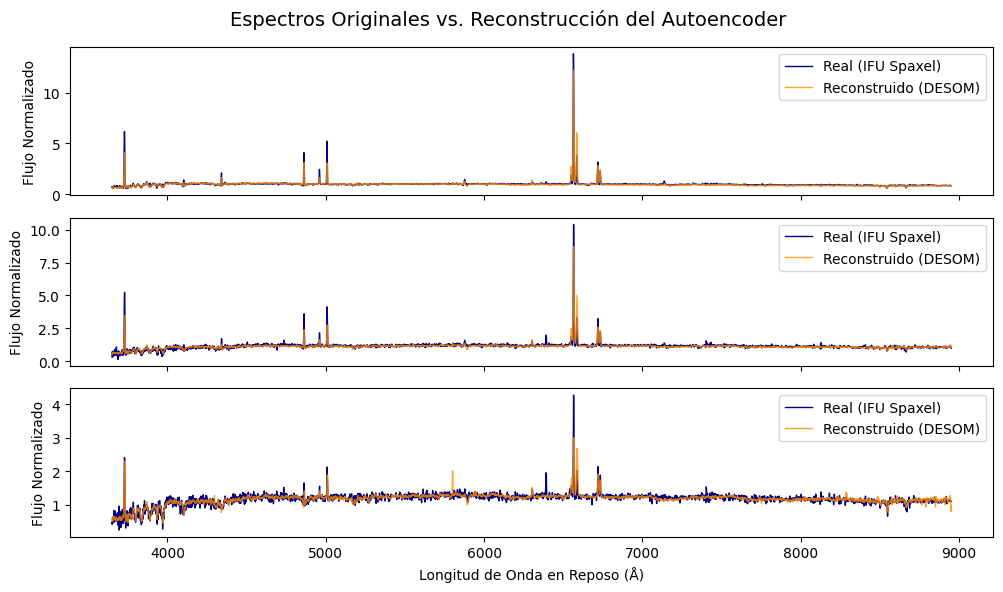


Generando 'Huellas Dactilares' (Fingerprints) de poblaciones estelares...


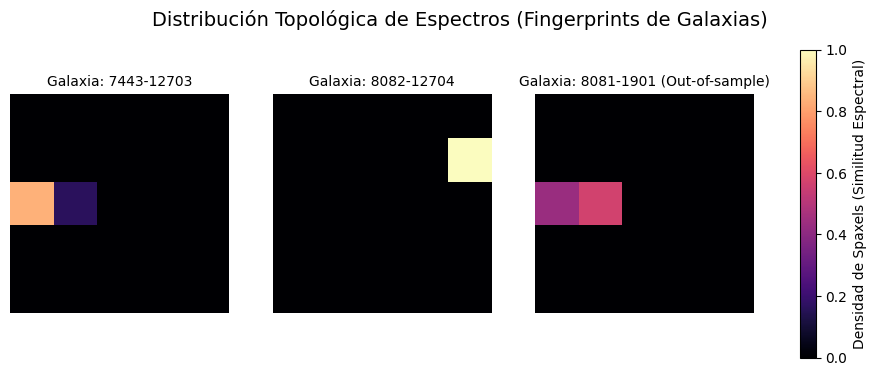

In [ ]:
model.eval()

def encode_and_reconstruct(array):
    zs, reconstructions = [], []
    with torch.no_grad():
        for chunk in torch.from_numpy(array).split(128):
            z = model.encoder(chunk.to(device))
            zs.append(z.cpu())
            reconstructions.append(model.decoder(z).cpu())
    return torch.cat(zs), torch.cat(reconstructions).numpy()

Z, reconstructed = encode_and_reconstruct(X)
prototypes = model.prototypes.detach().cpu()
distances = torch.cdist(Z, prototypes)
nearest = distances.topk(2, largest=False).indices
bmu = nearest[:, 0].numpy()

# 1. Gráficas de reconstrucción de espectros
print("Evaluando capacidad de reconstrucción espectral...")
test_indices = np.flatnonzero(test_mask)[:3]
fig, axes = plt.subplots(3, 1, figsize=(10, 6), sharex=True)
for ax, idx in zip(axes, test_indices):
    ax.plot(wave_grid, X[idx], lw=1, label="Real (IFU Spaxel)", color="navy")
    ax.plot(wave_grid, reconstructed[idx], lw=1, label="Reconstruido (DESOM)", color="darkorange", alpha=0.8)
    ax.legend(loc="upper right")
    ax.set_ylabel("Flujo Normalizado")
axes[-1].set_xlabel("Longitud de Onda en Reposo (Å)")
fig.suptitle("Espectros Originales vs. Reconstrucción del Autoencoder", fontsize=14)
plt.tight_layout()
plt.show()

# 2. Mapas de "Fingerprints" por galaxia
fingerprints = np.stack([
    np.bincount(bmu[owners == galaxy], minlength=SIDE * SIDE)
    for galaxy in GALAXIES
]).astype(float)
fingerprints /= fingerprints.sum(axis=1, keepdims=True) # Frecuencia relativa

print("\nGenerando 'Huellas Dactilares' (Fingerprints) de poblaciones estelares...")
fig, axes = plt.subplots(1, len(GALAXIES), figsize=(12, 4))
for ax, galaxy, fingerprint in zip(axes, GALAXIES, fingerprints):
    im = ax.imshow(
        fingerprint.reshape(SIDE, SIDE),
        origin="lower", vmin=0, vmax=fingerprints.max(), cmap="magma"
    )
    title = f"Galaxia: {galaxy}" + (" (Out-of-sample)" if galaxy == GALAXIES[-1] else "")
    ax.set_title(title, fontsize=10)
    ax.axis('off')

fig.colorbar(im, ax=list(axes), label="Densidad de Spaxels (Similitud Espectral)")
fig.suptitle("Distribución Topológica de Espectros (Fingerprints de Galaxias)", fontsize=14)
plt.show()

## Parte 4 · Refinamiento del Mapa (Abordando el problema de muestra pequeña)

Al utilizar una muestra diminuta (menos de 1000 espectros en lugar del millón utilizado en el artículo original), un SOM estándar tiende a sufrir de "nodos muertos" (nodos que nunca son asignados como ganadores) y un error topográfico elevado.

Para solucionar este artefacto y garantizar que el SOM represente la física subyacente correctamente:
1. **Inicialización por PCA:** Forzamos a los prototipos a alinearse con las dos componentes principales de mayor varianza del espacio latente.
2. **Batch SOM Update:** Aplicamos iteraciones estrictas de SOM directamente sobre los vectores latentes fijos (manteniendo el Encoder estático). Esto despliega la cuadrícula y reduce significativamente el error de cuantización.

### Algoritmo Batch SOM y Diagnósticos del Mapa

Para muestras pequeñas, la optimización por gradiente descendente puede dejar nodos muertos. El algoritmo **Batch SOM** actualiza directamente los prototipos del mapa sobre el espacio latente estático mediante un proceso analítico directo.

#### 1. Actualización Batch del Prototipo $m_j$
En cada iteración, el nuevo vector para cada prototipo $m_j$ se calcula como el promedio ponderado de todos los datos latentes, filtrados por la vecindad topológica y balanceados por peso:

$$m_j^{(t+1)} = \frac{\sum_{i=1}^{N_{\text{train}}} v_i \cdot K_{\sigma}(w_i, j) \cdot z_i}{\sum_{i=1}^{N_{\text{train}}} v_i \cdot K_{\sigma}(w_i, j)}$$

*   $z_i$: Coordenada latente fija del espectro $i$.
*   $v_i$: Peso asociado a la galaxia correspondiente para evitar el sesgo por sobre-representación de galaxias con excesivos spaxels ($v_i \propto 1/N_{\text{galaxy}}$).
*   $\sigma$ (`sigma`): Radio de vecindad que decrece según el esquema:

    $$\sigma_t = \sigma_{\text{ini}} \cdot \left(\frac{\sigma_{\text{fin}}}{\sigma_{\text{ini}}}\right)^{\frac{t}{T_{\text{max}}}}$$

    Donde $\sigma_{\text{ini}} = 2.5$, $\sigma_{\text{fin}} = 0.4$, $t$ es el paso actual y $T_{\text{max}} = 150$ iteraciones.

#### 2. Métricas de Diagnóstico
*   **Nodos Ocupados:** Número de nodos que son seleccionados al menos una vez como el nodo más cercano ($w_i$).
*   **Error Topográfico ($TE$):** Mide la preservación de la topología analizando si el primer ($w_i^{(1)}$) y el segundo ($w_i^{(2)}$) nodo más cercano a cada dato son adyacentes en la cuadrícula:

    $$TE = \frac{1}{N} \sum_{i=1}^{N} I(\text{dist}_{\text{grid}}(w_i^{(1)}, w_i^{(2)}) > 1)$$

    Donde $I(\cdot)$ es la función indicadora (retorna 1 si se cumple la condición, 0 si no).
*   **Distancia de Cuantización ($QD$):** Mide qué tan bien representan los prototipos del mapa a la muestra en el espacio latente:

    $$QD = \frac{1}{N} \sum_{i=1}^{N} \|z_i - m_{w_i}\|$$

In [ ]:
# Cálculos de diagnóstico y reestructuración del SOM para muestras pequeñas
with torch.no_grad():
    latent_train = torch.cat([model.encoder(batch.to(device)).cpu() for batch in X_train.split(128)])

z = latent_train.float()
n_nodes = SIDE * SIDE

# Ajuste de pesos por galaxia para evitar sesgos de sobre-representación
train_owners = owners[train_mask]
galaxy_ids, galaxy_counts = np.unique(train_owners, return_counts=True)
counts_by_galaxy = dict(zip(galaxy_ids, galaxy_counts))

weights = torch.tensor([1.0 / counts_by_galaxy[g] for g in train_owners], dtype=z.dtype)
weights /= weights.sum()

# Inicialización espacialmente ordenada mediante PCA
center = (weights[:, None] * z).sum(dim=0)
centered = z - center
_, singular_values, vh = torch.linalg.svd(centered * weights.sqrt()[:, None], full_matrices=False)

coords = torch.cartesian_prod(torch.arange(SIDE), torch.arange(SIDE)).float()
grid_dist2 = torch.cdist(coords, coords).square()
unit_coords = 2 * coords / (SIDE - 1) - 1

p = center[None, :] + (unit_coords * (2 * singular_values[:2])) @ vh[:2]

def training_diagnostics(prototypes):
    distances = torch.cdist(z, prototypes)
    nearest_two = distances.topk(2, largest=False).indices
    winners = nearest_two[:, 0]
    occupancy = torch.bincount(winners, minlength=n_nodes)
    separation = (coords[nearest_two[:, 0]] - coords[nearest_two[:, 1]]).abs().sum(dim=1)

    topo = (separation != 1).float().mean().item()
    quantization = distances.min(dim=1).values.mean().item()
    return int((occupancy > 0).sum()), topo, quantization

print("Diagnosticando inicialización PCA...")
occupied, topo, quant = training_diagnostics(p)
print(f"Inicialización -> Nodos ocupados: {occupied}/{n_nodes} | Error Topográfico: {topo:.3f} | Distancia de Cuantización: {quant:.4f}")

# Algoritmo Batch SOM de convergencia topológica
SCHEDULE_ITER, STOP_ITER = 150, 90
print("\nEjecutando ajuste de grilla (Batch SOM)...")

for step in range(STOP_ITER):
    progress = step / (SCHEDULE_ITER - 1)
    sigma = 2.5 * (0.4 / 2.5) ** progress

    distances = torch.cdist(z, p)
    winners = distances.argmin(dim=1)

    neighborhood = torch.exp(-grid_dist2[winners] / (2 * sigma**2))
    contributions = neighborhood * weights[:, None]
    denominator = contributions.sum(dim=0)

    updated = (contributions.T @ z) / denominator.clamp_min(1e-12)[:, None]
    supported = denominator > 1e-12
    p[supported] = updated[supported]

    if (step + 1) % 30 == 0:
        occupied, topo, quantization = training_diagnostics(p)
        print(f"Iteración {step + 1:3d} | Radio \u03C3 = {sigma:.2f} | Nodos ocupados = {occupied:2d}/{n_nodes} | Error Topográfico = {topo:.3f}")

with torch.no_grad():
    model.prototypes.copy_(p.to(device=model.prototypes.device, dtype=model.prototypes.dtype))

print("\n¡Ajuste topológico completado! La red ahora está preparada para el análisis de Fingerprints con mayor precisión y menos 'nodos muertos'.")

Diagnosticando inicialización PCA...
Inicialización -> Nodos ocupados: 11/25 | Error Topográfico: 0.000 | Distancia de Cuantización: 0.4371

Ejecutando ajuste de grilla (Batch SOM)...
Iteración  30 | Radio σ = 1.75 | Nodos ocupados = 16/25 | Error Topográfico = 0.052
Iteración  60 | Radio σ = 1.21 | Nodos ocupados = 22/25 | Error Topográfico = 0.038
Iteración  90 | Radio σ = 0.84 | Nodos ocupados = 21/25 | Error Topográfico = 0.065

¡Ajuste topológico completado! La red ahora está preparada para el análisis de Fingerprints con mayor precisión y menos 'nodos muertos'.


### Evaluación de Resultados con el SOM Refinado

Ahora que los prototipos del SOM han sido reordenados y optimizados mediante el algoritmo Batch SOM para evitar nodos vacíos y mejorar el error topográfico, volvemos a calcular el nodo ganador (BMU) para cada spaxel y visualizamos las nuevas "Huellas Dactilares" (Fingerprints) resultantes.

Generando nuevas 'Huellas Dactilares' (Fingerprints) tras el refinamiento del SOM...


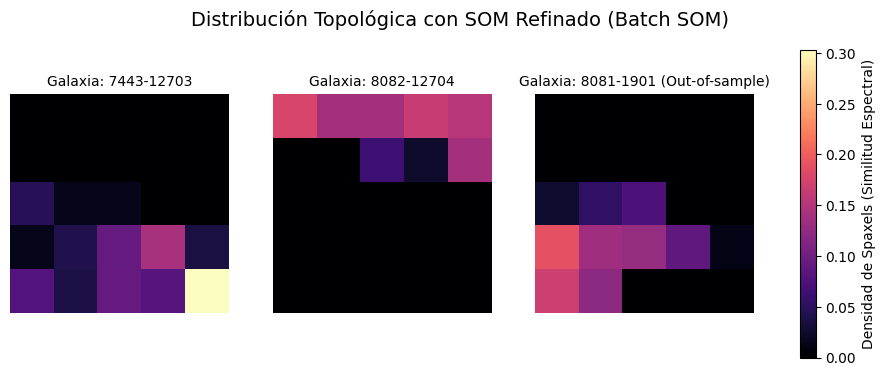

In [ ]:
# 1. Recalcular las proyecciones y distancias con los prototipos refinados
model.eval()
with torch.no_grad():
    # Obtener el estado de los prototipos refinados directamente desde el modelo
    prototypes_refined = model.prototypes.detach().cpu()

    # Calcular las representaciones latentes de todo el conjunto de espectros (X)
    Z_refined = []
    for chunk in torch.from_numpy(X).split(128):
        z_chunk = model.encoder(chunk.to(device))
        Z_refined.append(z_chunk.cpu())
    Z_refined = torch.cat(Z_refined)

# Encontrar los nuevos nodos ganadores (BMU)
distances_refined = torch.cdist(Z_refined, prototypes_refined)
bmu_refined = distances_refined.argmin(dim=1).numpy()

# 2. Re-generar los mapas de "Fingerprints" por galaxia con el SOM ajustado
fingerprints_refined = np.stack([
    np.bincount(bmu_refined[owners == galaxy], minlength=SIDE * SIDE)
    for galaxy in GALAXIES
]).astype(float)

# Evitar divisiones por cero si alguna galaxia no tuviera spaxels
for i in range(len(GALAXIES)):
    total_spaxels = fingerprints_refined[i].sum()
    if total_spaxels > 0:
        fingerprints_refined[i] /= total_spaxels

print("Generando nuevas 'Huellas Dactilares' (Fingerprints) tras el refinamiento del SOM...")
fig, axes = plt.subplots(1, len(GALAXIES), figsize=(12, 4))
for ax, galaxy, fingerprint in zip(axes, GALAXIES, fingerprints_refined):
    im = ax.imshow(
        fingerprint.reshape(SIDE, SIDE),
        origin="lower", vmin=0, vmax=fingerprints_refined.max(), cmap="magma"
    )
    title = f"Galaxia: {galaxy}" + (" (Out-of-sample)" if galaxy == GALAXIES[-1] else "")
    ax.set_title(title, fontsize=10)
    ax.axis('off')

fig.colorbar(im, ax=list(axes), label="Densidad de Spaxels (Similitud Espectral)")
fig.suptitle("Distribución Topológica con SOM Refinado (Batch SOM)", fontsize=14)
plt.show()

### Calidad de Reconstrucción Espectral y Perfiles Físicos de los Nodos

Graficamos nuevamente la excelente calidad de reconstrucción de los espectros individuales de la galaxia de prueba *out-of-sample* (que no cambia dado que los pesos del Decoder permanecieron estáticos) y, adicionalmente, visualizamos los perfiles de espectros físicos que representan cada uno de los nodos de nuestra cuadrícula refinada del SOM.

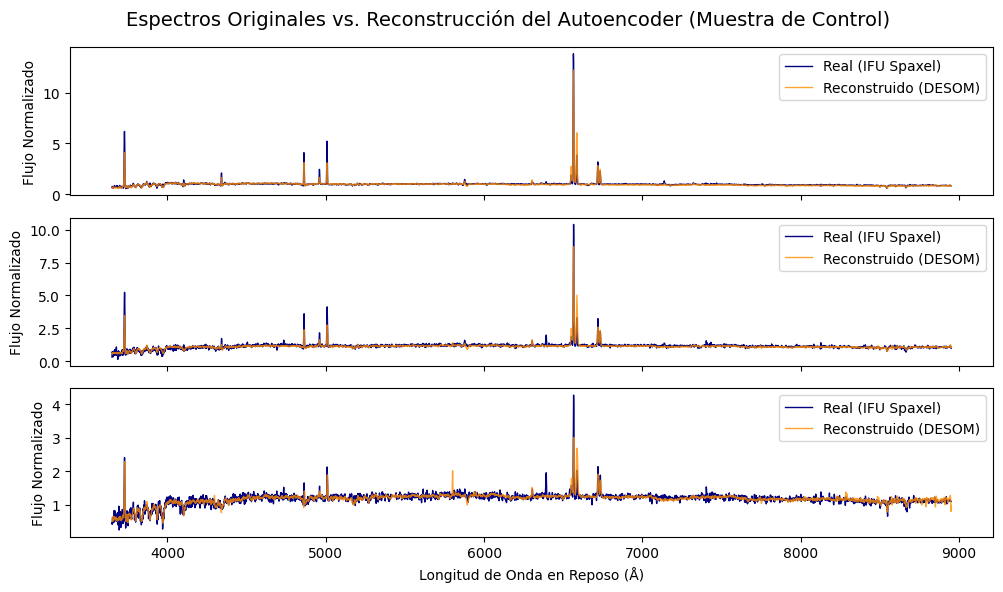

Visualizando los espectros característicos aprendidos por cada nodo del SOM (Matriz 5x5)...


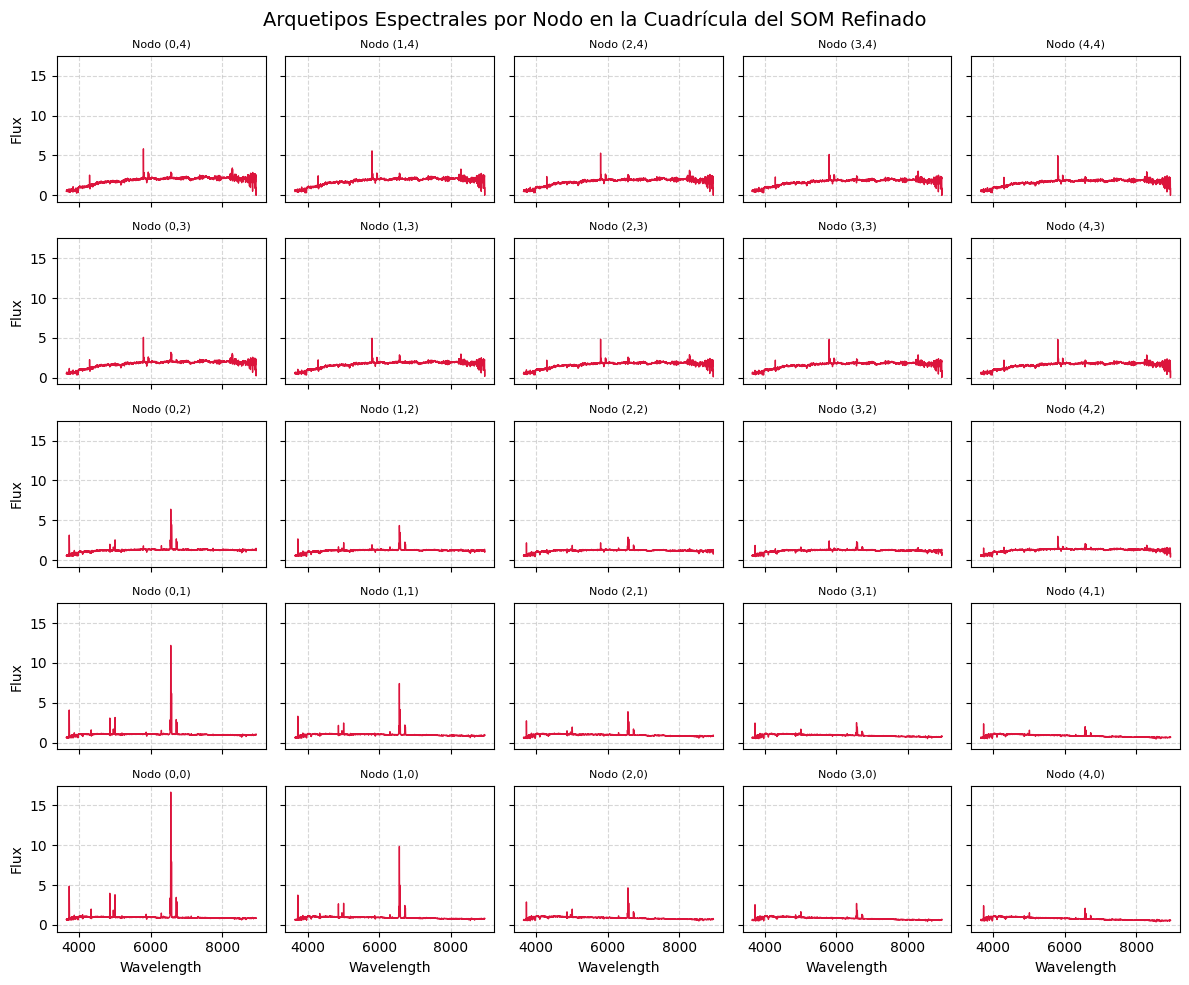

In [ ]:
# 1. Visualizar de nuevo la reconstrucción del Autoencoder para la galaxia out-of-sample
fig, axes = plt.subplots(3, 1, figsize=(10, 6), sharex=True)
for ax, idx in zip(axes, test_indices[:3]):
    ax.plot(wave_grid, X[idx], lw=1, label="Real (IFU Spaxel)", color="navy")
    ax.plot(wave_grid, reconstructed[idx], lw=1, label="Reconstruido (DESOM)", color="darkorange", alpha=0.8)
    ax.legend(loc="upper right")
    ax.set_ylabel("Flujo Normalizado")
axes[-1].set_xlabel("Longitud de Onda en Reposo (Å)")
fig.suptitle("Espectros Originales vs. Reconstrucción del Autoencoder (Muestra de Control)", fontsize=14)
plt.tight_layout()
plt.show()

# 2. Reconstruir físicamente los prototipos del SOM para ver el gradiente físico del mapa
with torch.no_grad():
    # Decodificamos los prototipos del SOM refinados al espacio físico de los espectros
    reconstructed_prototypes = model.decoder(prototypes_refined.to(device)).cpu().numpy()

print("Visualizando los espectros característicos aprendidos por cada nodo del SOM (Matriz 5x5)...")
fig, axes = plt.subplots(SIDE, SIDE, figsize=(12, 10), sharex=True, sharey=True)
for i in range(SIDE):
    for j in range(SIDE):
        node_idx = i * SIDE + j
        ax = axes[SIDE - 1 - i, j] # Voltear verticalmente para que coincida con el origin='lower' de imshow
        ax.plot(wave_grid, reconstructed_prototypes[node_idx], color="crimson", lw=1)
        ax.set_title(f"Nodo ({j},{i})", fontsize=8)
        ax.grid(True, linestyle="--", alpha=0.5)
        if i == 0:
            ax.set_xlabel("Wavelength")
        if j == 0:
            ax.set_ylabel("Flux")

fig.suptitle("Arquetipos Espectrales por Nodo en la Cuadrícula del SOM Refinado", fontsize=14)
plt.tight_layout()
plt.show()